# Uptake Comparison Across Tools

This notebook compares the attached uptake-by-cells outputs from BioDynaMo, Chaste, CompuTiX, PhysiCell, and TiSim using both relative error and absolute error against the analytical solution.

The workflow is split into the same steps as the decay comparison notebook:
1. Load the result files into one common table using both the whole-box average concentration and the center concentration.
2. Load the analytical reference table.
3. Match the rounded analytical time points and aggregate duplicate matches at each time point.
4. Compute the relative error and the absolute error for every run and rank the runs within each tool.
5. Keep only the run with the smallest mean error for each tool and compare those best runs directly.

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml


## Step 1: Define Study Paths And Shared Physical Parameters

The four tools store their outputs in different formats, but they all represent the same uptake-by-cells setup.
For this comparison we use both the whole-box average concentration and the center concentration so the workflow matches the decay notebook structure.

In [8]:
ROOT = Path('/home/tntiniak/Work/observatory_benchmark')

BIODYNAMO_DIR = ROOT / 'Biodynamo' / 'diffusion_uptake_test'
CHASTE_DIR = ROOT / 'Chaste' / 'DiffusionWithCells'
COMPUTIX_DIR = ROOT / 'CompuTiX' / 'diffusion_single' / 'CellsAtCenter'
PHYSICELL_DIR = ROOT / 'PhysiCell' / 'results' / 'diffusion_uptake_fixed_positions'
PHYSICELL_EXPORT_FILENAME = 'physicell_uptake_plot_data.csv'
ANALYTICAL_DIR = ROOT / 'analytical_solutions' / 'diffusion' / 'Cellsatcenter'
ANALYTICAL_PARAMETERS = {
    'box_length_um': 240.0,
    'initial_concentration_uM': 10.0,
}


## Step 2: Load The Analytical Reference Table

The analytical reference comes from the uptake analytical CSV.

Both the whole-box average concentration and the center concentration are loaded so we can compute relative and absolute error for the same two metrics used in the decay notebook.

In [9]:
analytical_df = pd.read_csv(
    ANALYTICAL_DIR / 'analytical_values.csv',
    usecols=['time_min', 'center_concentration_uM', 'average_concentration_uM'],
    dtype={
        'time_min': float,
        'center_concentration_uM': float,
        'average_concentration_uM': float,
    },
)
analytical_df['time_min'] = analytical_df['time_min'].round(2)

analytical_df

,time_min,center_concentration_uM,average_concentration_uM
0,0.0,10.000000,10.000000
1,0.1,8.947337,9.986105
2,0.2,8.458508,9.972221
3,0.3,8.182195,9.958393
4,0.4,7.999790,9.944769
...,...,...,...
96,9.6,7.139371,9.783745
97,9.7,7.139366,9.783744
98,9.8,7.139362,9.783743
99,9.9,7.139357,9.783742


## Step 3: Load Every Attached Result Into One Common Table

Each loader returns a table with the same columns: tool name, run identifier, time in minutes, spatial resolution in um, whole-box average concentration in uM, and the concentration used for the center comparison metric.

BioDynaMo uses columns 2 and 3 from the text file, Chaste uses the center and average columns from its text output, CompuTiX uses `c_central` and `c_domain`, PhysiCell now supports both the legacy exported schema and the fixed-position raw schema (using `origin_center_uM` for center comparison when available), and TiSim reads the uploaded uptake-average and uptake-center workbook sheets converted to CSV.

In [ ]:
def format_resolution_label(tool: str, dx_um: float, n_voxels_per_dim: int | None = None, dt_min: float | None = None) -> str:
    if tool in {'BioDynaMo', 'Chaste'}:
        return f'N={n_voxels_per_dim} voxels/dim, dx={dx_um:.0f} um'

    if tool == 'CompuTiX':
        return f'N={n_voxels_per_dim} voxels/dim, dx={dx_um:.2f} um, dt={dt_min:.1e} min'

    if tool == 'PhysiCell':
        return f'voxel size={dx_um:.0f} um'

    if tool == 'TiSim':
        return f'N={n_voxels_per_dim} bins, dx={dx_um:.0f} um'

    return f'dx={dx_um:.0f} um'


def load_biodynamo_runs() -> list[pd.DataFrame]:
    runs = []
    for csv_path in sorted(BIODYNAMO_DIR.glob('data_*.csv')):
        n_voxels_per_dim = int(csv_path.stem.split('_')[1])
        dx_um = ANALYTICAL_PARAMETERS['box_length_um'] / n_voxels_per_dim
        frame = pd.read_csv(csv_path, sep=r'\s+', header=None, names=['time_min', 'average_uM', 'center_uM'])
        frame['time_min'] = frame['time_min'].round(2)
        run_id = f'BioDynaMo_N_{n_voxels_per_dim}'
        frame = frame.assign(
            tool='BioDynaMo',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=np.nan,
            average_source='text file column 2: average_uM',
            center_source='text file column 3: center_uM',
            resolution_label=format_resolution_label('BioDynaMo', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim),
        )
        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']])
    return runs


def load_chaste_runs() -> list[pd.DataFrame]:
    runs = []
    for txt_path in sorted(CHASTE_DIR.glob('*.txt')):
        n_voxels_per_dim = int(txt_path.stem)
        dx_um = ANALYTICAL_PARAMETERS['box_length_um'] / n_voxels_per_dim
        frame = pd.read_csv(txt_path, sep=r'\s+', header=None, names=['time_min', 'center_uM', 'average_uM'])
        frame['time_min'] = frame['time_min'].round(2)
        run_id = f'Chaste_N_{n_voxels_per_dim}'
        frame = frame.assign(
            tool='Chaste',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=np.nan,
            average_source='txt column 3: average_uM',
            center_source='txt column 2: center_uM',
            resolution_label=format_resolution_label('Chaste', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim),
        )
        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']])
    return runs


def load_computix_runs() -> list[pd.DataFrame]:
    runs = []
    for yaml_path in sorted(COMPUTIX_DIR.glob('dt-s-*_N-*.yaml')):
        data = yaml.safe_load(yaml_path.read_text())
        dx_um = float(data['dx']['values']) * 1e6
        dt_min = float(data['dt']['values']) / 60.0
        n_voxels_per_dim = int(data['N']['values'])
        frame = pd.DataFrame({
            'time_min': np.round(np.array(data['time_series']['values']['t']['values'], dtype=float) / 60.0, 2),
            'average_uM': 1e3 * np.array(data['time_series']['values']['c_domain']['values'], dtype=float),
            'center_uM': 1e3 * np.array(data['time_series']['values']['c_central']['values'], dtype=float),
        })
        run_id = f'CompuTiX_N_{n_voxels_per_dim}_dt_{dt_min:.5g}min'
        frame = frame.assign(
            tool='CompuTiX',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=dt_min,
            average_source='YAML time_series.values.c_domain.values',
            center_source='YAML time_series.values.c_central.values',
            resolution_label=format_resolution_label('CompuTiX', dx_um=dx_um, n_voxels_per_dim=n_voxels_per_dim, dt_min=dt_min),
        )
        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']])
    return runs


def load_physicell_runs() -> list[pd.DataFrame]:
    # Support both legacy exports and fixed-position raw run exports.
    csv_paths = sorted(PHYSICELL_DIR.glob(f'*/{PHYSICELL_EXPORT_FILENAME}'))

    if not csv_paths:
        raise FileNotFoundError(
            f'No PhysiCell export CSVs found in {PHYSICELL_DIR}. Run the PhysiCell uptake export first.'
        )

    runs = []
    for csv_path in csv_paths:
        frame = pd.read_csv(csv_path)

        if 'time_min' not in frame.columns or 'average_uM' not in frame.columns:
            raise ValueError(f'{csv_path} must contain at least time_min and average_uM columns.')

        if 'origin_center_uM' in frame.columns:
            center_values = frame['origin_center_uM']
            center_source = 'CSV origin_center_uM (trilinear interpolation at origin)'
        elif 'center_uM' in frame.columns and 'center_source' in frame.columns:
            center_values = frame['center_uM']
            center_source = frame['center_source'].iloc[0]
        elif 'center_uM' in frame.columns:
            center_values = frame['center_uM']
            center_source = 'CSV center_uM'
        elif 'cell_voxel_average_uM' in frame.columns:
            center_values = frame['cell_voxel_average_uM']
            center_source = 'CSV cell_voxel_average_uM (average over occupied cell voxels)'
        else:
            raise ValueError(
                f'{csv_path} is missing a center concentration column. Expected one of '
                "['origin_center_uM', 'center_uM', 'cell_voxel_average_uM']."
            )

        tool_value = frame['tool'].iloc[0] if 'tool' in frame.columns else 'PhysiCell'
        run_id_value = frame['run_id'].iloc[0] if 'run_id' in frame.columns else csv_path.parent.name
        dx_value = float(frame['dx_um'].iloc[0]) if 'dx_um' in frame.columns else np.nan

        if 'dt_min' in frame.columns:
            dt_value = frame['dt_min'].iloc[0]
        elif 'dt_diffusion_min' in frame.columns:
            dt_value = frame['dt_diffusion_min'].iloc[0]
        else:
            dt_value = np.nan

        average_source = frame['average_source'].iloc[0] if 'average_source' in frame.columns else 'CSV average_uM'

        if 'resolution_label' in frame.columns:
            resolution_label = frame['resolution_label'].iloc[0]
        elif np.isfinite(dx_value):
            resolution_label = format_resolution_label('PhysiCell', dx_um=dx_value)
        else:
            resolution_label = f'run={run_id_value}'

        standardized = pd.DataFrame({
            'tool': tool_value,
            'run_id': run_id_value,
            'dx_um': dx_value,
            'dt_min': dt_value,
            'average_source': average_source,
            'center_source': center_source,
            'resolution_label': resolution_label,
            'time_min': frame['time_min'].round(2),
            'average_uM': frame['average_uM'],
            'center_uM': center_values,
        })

        runs.append(standardized)

    return runs


def load_tisim_runs() -> list[pd.DataFrame]:
    tisim_dir = ROOT / 'Tisim' / 'diffusion_uptake_test'
    runs = []

    for csv_path in sorted(tisim_dir.glob('data_*.csv')):
        n_bins = int(csv_path.stem.split('_')[1])
        dx_um = ANALYTICAL_PARAMETERS['box_length_um'] / n_bins
        frame = pd.read_csv(csv_path)
        frame['time_min'] = frame['time_min'].round(2)
        run_id = f'TiSim_N_{n_bins}'
        frame = frame.assign(
            tool='TiSim',
            run_id=run_id,
            dx_um=dx_um,
            dt_min=np.nan,
            average_source='Excel uptake average sheet concentration column',
            center_source='Excel uptake center sheet concentration column',
            resolution_label=format_resolution_label('TiSim', dx_um=dx_um, n_voxels_per_dim=n_bins),
        )
        runs.append(frame[['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label', 'time_min', 'average_uM', 'center_uM']])
    return runs


all_runs = pd.concat(
    load_biodynamo_runs() + load_chaste_runs() + load_computix_runs() + load_physicell_runs() + load_tisim_runs(),
    ignore_index=True,
)

assert not all_runs['average_uM'].isna().any()
assert not all_runs['center_uM'].isna().any()

run_catalog = (
    all_runs[
        ['tool', 'run_id', 'dx_um', 'dt_min', 'average_source', 'center_source', 'resolution_label']
    ]
    .drop_duplicates()
    .sort_values(['tool', 'dx_um', 'dt_min'])
)

tool_colors = {
    'BioDynaMo': '#ff7f00',
    'Chaste': '#377eb8',
    'CompuTiX': '#fd2a2a',
    'PhysiCell': '#4daf4a',
    'TiSim': '#984ea3',
}

metric_titles = {
    'average': 'Whole-box average concentration',
    'center': 'Center concentration',
}

metric_file_tokens = {
    'average': 'whole_box_average',
    'center': 'center_concentration',
}

plot_output_dir = ROOT / 'ResultAnalysis' / 'uptake_tools_comparison_plots'
plot_output_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 160,
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})


def style_axis(axis) -> None:
    axis.set_facecolor('#fbfbfc')
    axis.grid(True, axis='y', linestyle='--', linewidth=0.8, alpha=0.35)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_color('#4a4a4a')
    axis.spines['bottom'].set_color('#4a4a4a')


def save_and_show(fig, filename: str) -> None:
    fig.savefig(plot_output_dir / filename, bbox_inches='tight', dpi=300, facecolor='white')
    plt.show()
    plt.close(fig)


run_catalog

## Step 4: Match Rounded Analytical Time Points And Aggregate Duplicate Matches

The analytical CSV is matched on the same rounded time grid used by the tool outputs.

Each run is first matched only on time points that are present in both the run output and the analytical table. After the relative error and absolute error are computed, duplicate matches at the same time point are aggregated to one value per tool, run, metric, and time. This removes the rounded-time duplication artifact while keeping the common-time comparison approach.

In [ ]:
analytical_reference = analytical_df.rename(
    columns={
        'center_concentration_uM': 'analytical_center_uM',
        'average_concentration_uM': 'analytical_average_uM',
    }
).copy()

comparison = all_runs.copy()
comparison['time_min'] = comparison['time_min'].round(2)

comparison = comparison.merge(
    analytical_reference,
    on='time_min',
    how='inner',
    validate='many_to_one',
)

comparison_average = comparison.assign(
    metric='average',
    simulated_uM=comparison['average_uM'],
    analytical_uM=comparison['analytical_average_uM'],
    source_column=comparison['average_source'],
)

comparison_center = comparison.assign(
    metric='center',
    simulated_uM=comparison['center_uM'],
    analytical_uM=comparison['analytical_center_uM'],
    source_column=comparison['center_source'],
)

comparison = pd.concat([comparison_average, comparison_center], ignore_index=True)

comparison['relative_error_percent'] = (
    100.0
    * (comparison['simulated_uM'] - comparison['analytical_uM']).abs()
    / comparison['analytical_uM'].abs()
)
comparison['absolute_error_uM'] = (comparison['simulated_uM'] - comparison['analytical_uM']).abs()

comparison = (
    comparison.groupby(
        ['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label', 'time_min'],
        dropna=False,
    )
    .agg(
        relative_error_percent=('relative_error_percent', 'mean'),
        absolute_error_uM=('absolute_error_uM', 'mean'),
        simulated_uM=('simulated_uM', 'mean'),
        analytical_uM=('analytical_uM', 'first'),
        source_column=('source_column', 'first'),
    )
    .reset_index()
)

relative_run_metrics = (
    comparison.groupby(['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'], dropna=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_relative_error_percent=('relative_error_percent', 'mean'),
        max_relative_error_percent=('relative_error_percent', 'max'),
        rmse_percent=('relative_error_percent', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .reset_index()
    .sort_values(['metric', 'tool', 'mean_relative_error_percent', 'dx_um', 'dt_min'])
)

absolute_run_metrics = (
    comparison.groupby(['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'], dropna=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_absolute_error_uM=('absolute_error_uM', 'mean'),
        max_absolute_error_uM=('absolute_error_uM', 'max'),
        rmse_uM=('absolute_error_uM', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .reset_index()
    .sort_values(['metric', 'tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])
)

relative_run_metrics

,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_relative_error_percent,max_relative_error_percent,rmse_percent
2,average,BioDynaMo,BioDynaMo_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",101,0.077446,0.098523,0.083367
1,average,BioDynaMo,BioDynaMo_N_24,10.0,NaN,"N=24 voxels/dim, dx=10 um",101,0.160477,0.202272,0.172360
0,average,BioDynaMo,BioDynaMo_N_12,20.0,NaN,"N=12 voxels/dim, dx=20 um",100,0.320970,0.401158,0.343997
3,average,BioDynaMo,BioDynaMo_N_6,40.0,NaN,"N=6 voxels/dim, dx=40 um",100,0.690016,0.835654,0.731206
6,average,Chaste,Chaste_N_48,5.0,NaN,"N=48 voxels/dim, dx=5 um",101,0.128856,0.151674,0.133328
...,...,...,...,...,...,...,...,...,...,...
100,center,PhysiCell,dx_20um__uptake_12044__dtdiff_0p005min__volume...,20.0,0.005,voxel size=20 um,101,69.308131,70.463212,69.668285
98,center,PhysiCell,dx_20um__uptake_12044__dtdiff_0p005min__volume...,20.0,0.005,voxel size=20 um,101,69.643256,70.798788,70.004872
144,center,TiSim,TiSim_N_20,12.0,NaN,"N=20 bins, dx=12 um",101,0.737177,0.875830,0.758906
143,center,TiSim,TiSim_N_10,24.0,NaN,"N=10 bins, dx=24 um",101,4.782177,5.207004,4.841721


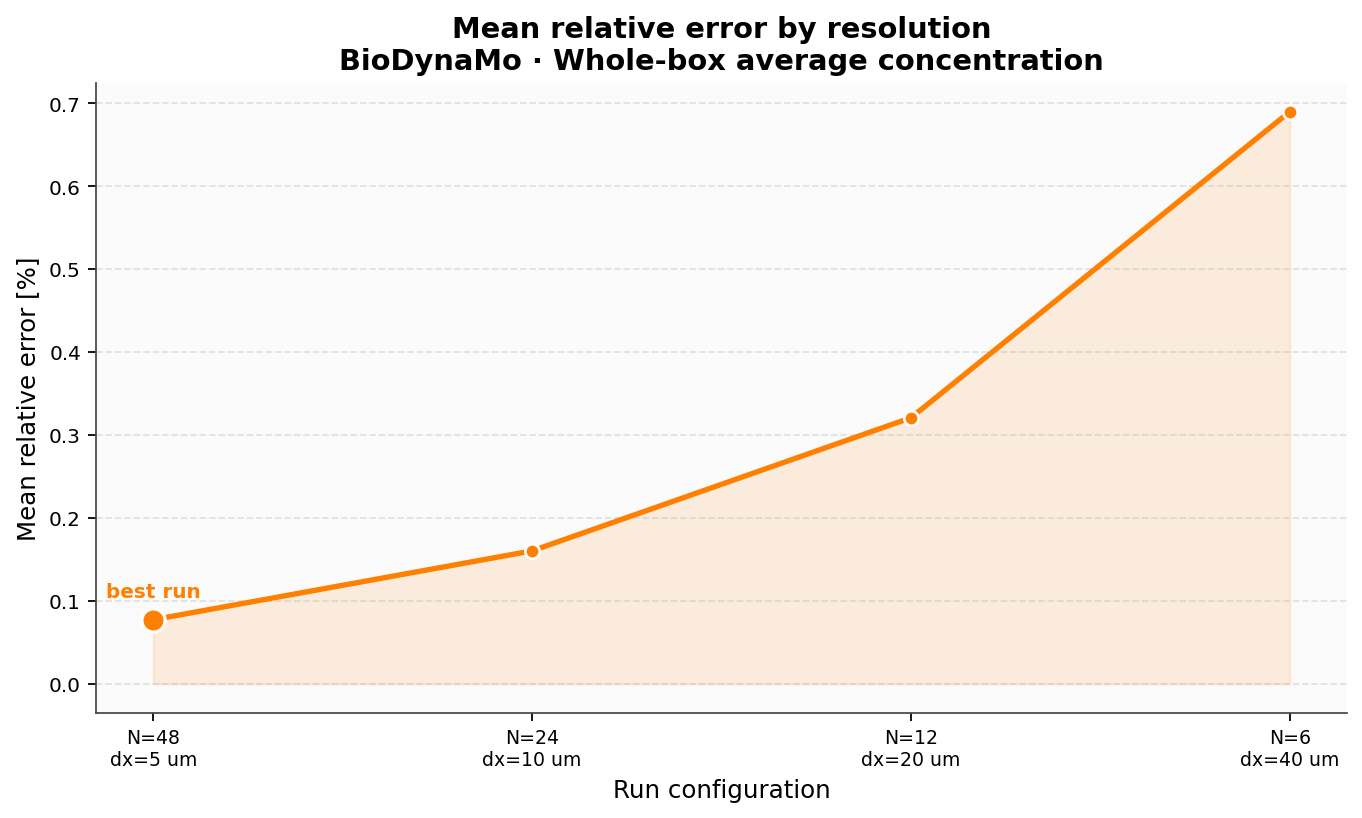

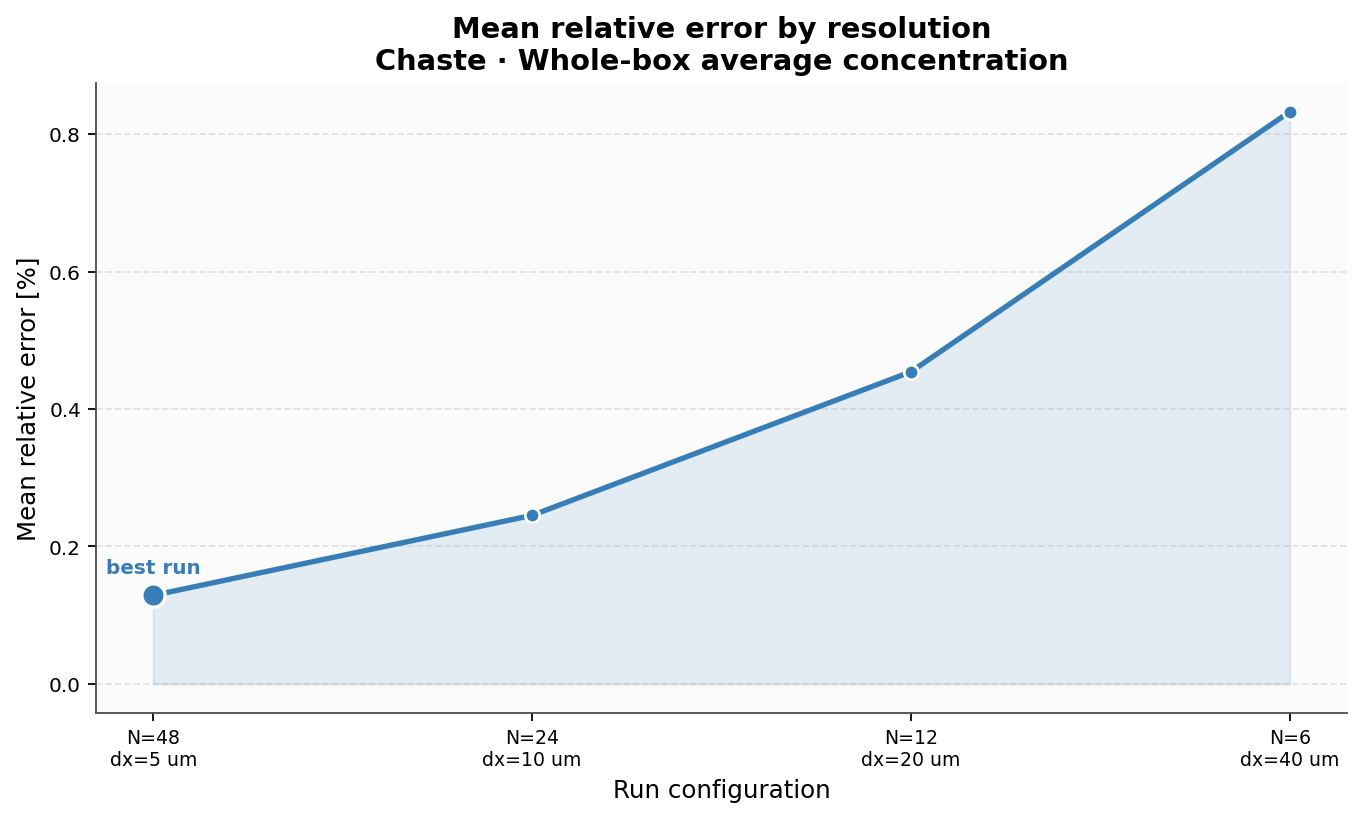

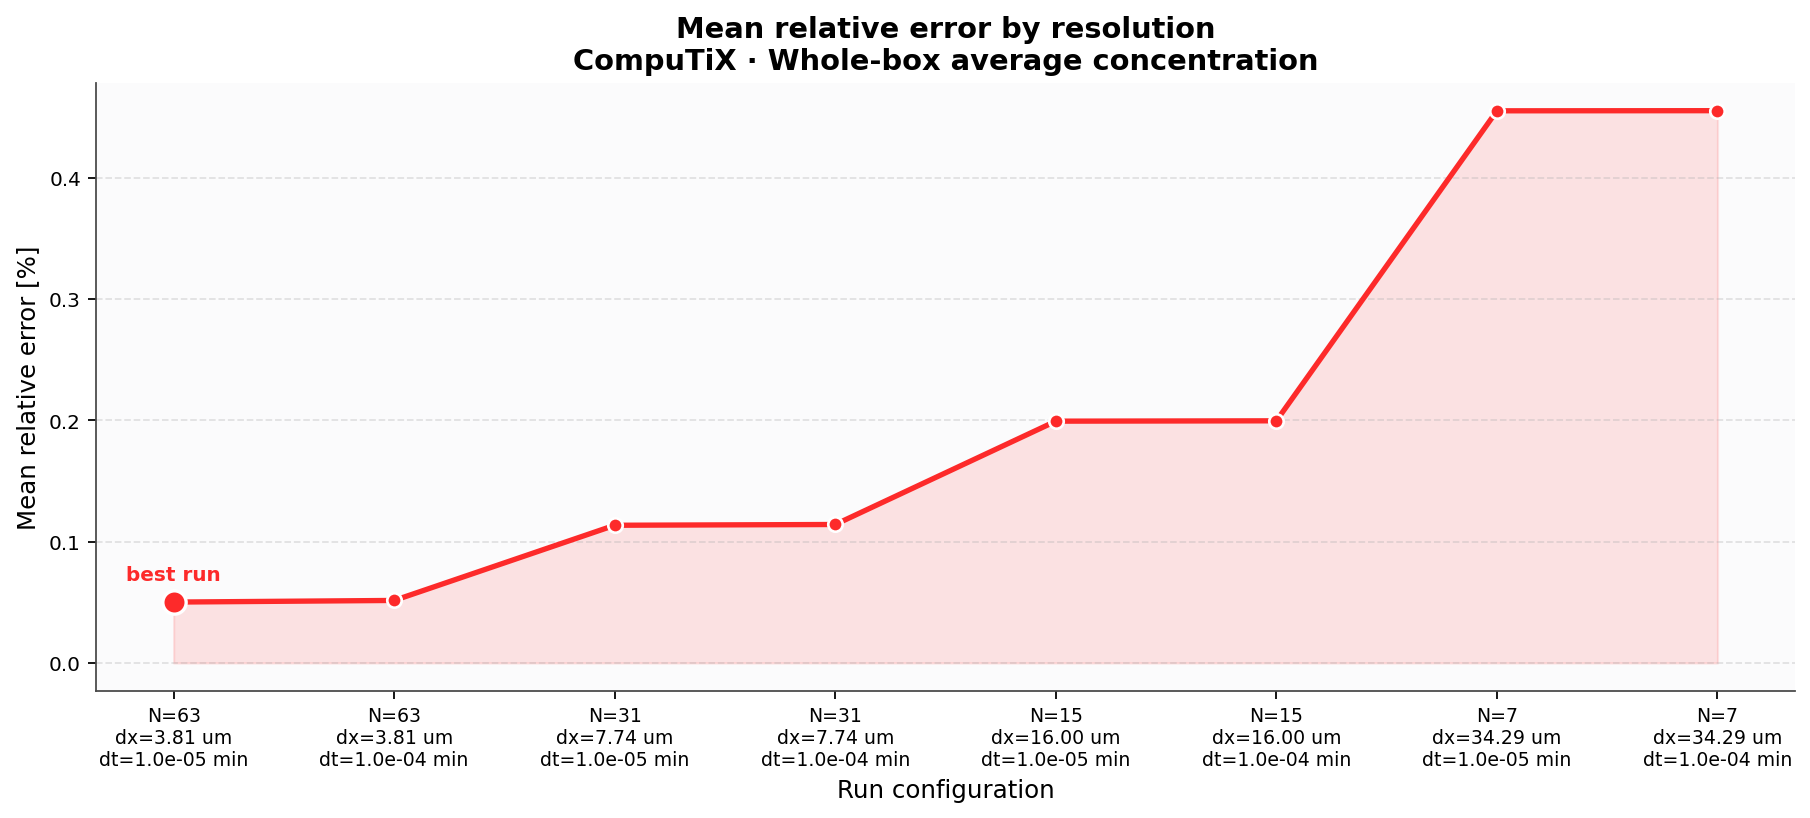

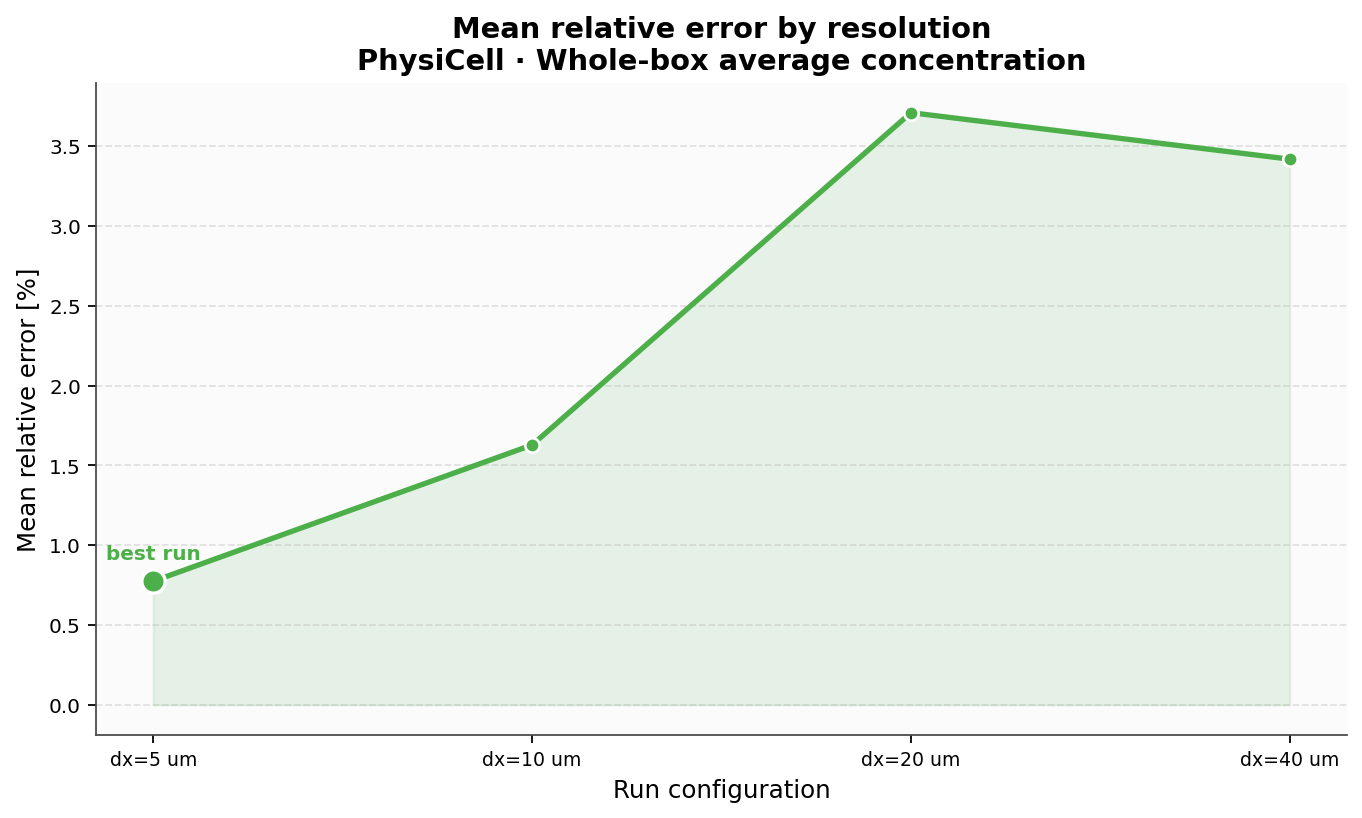

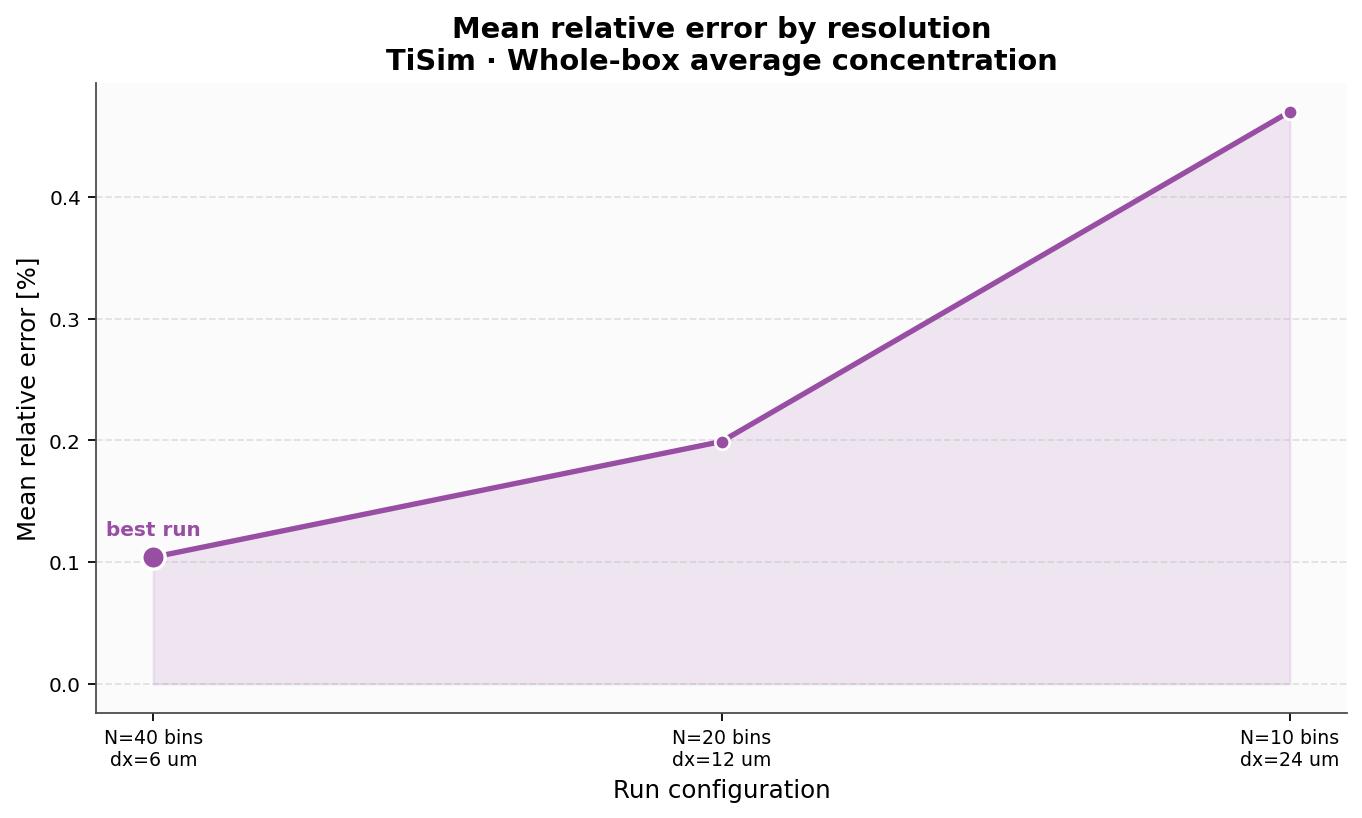

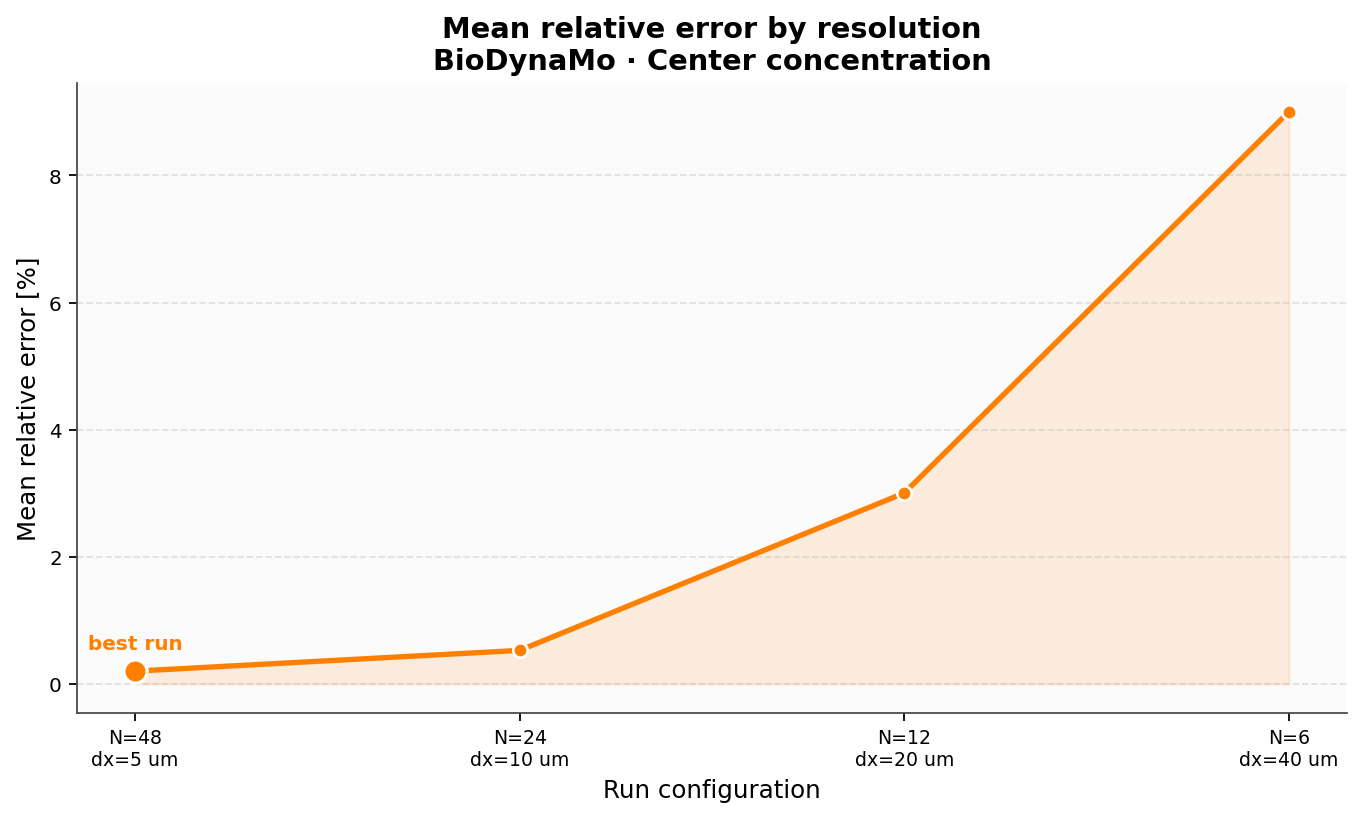

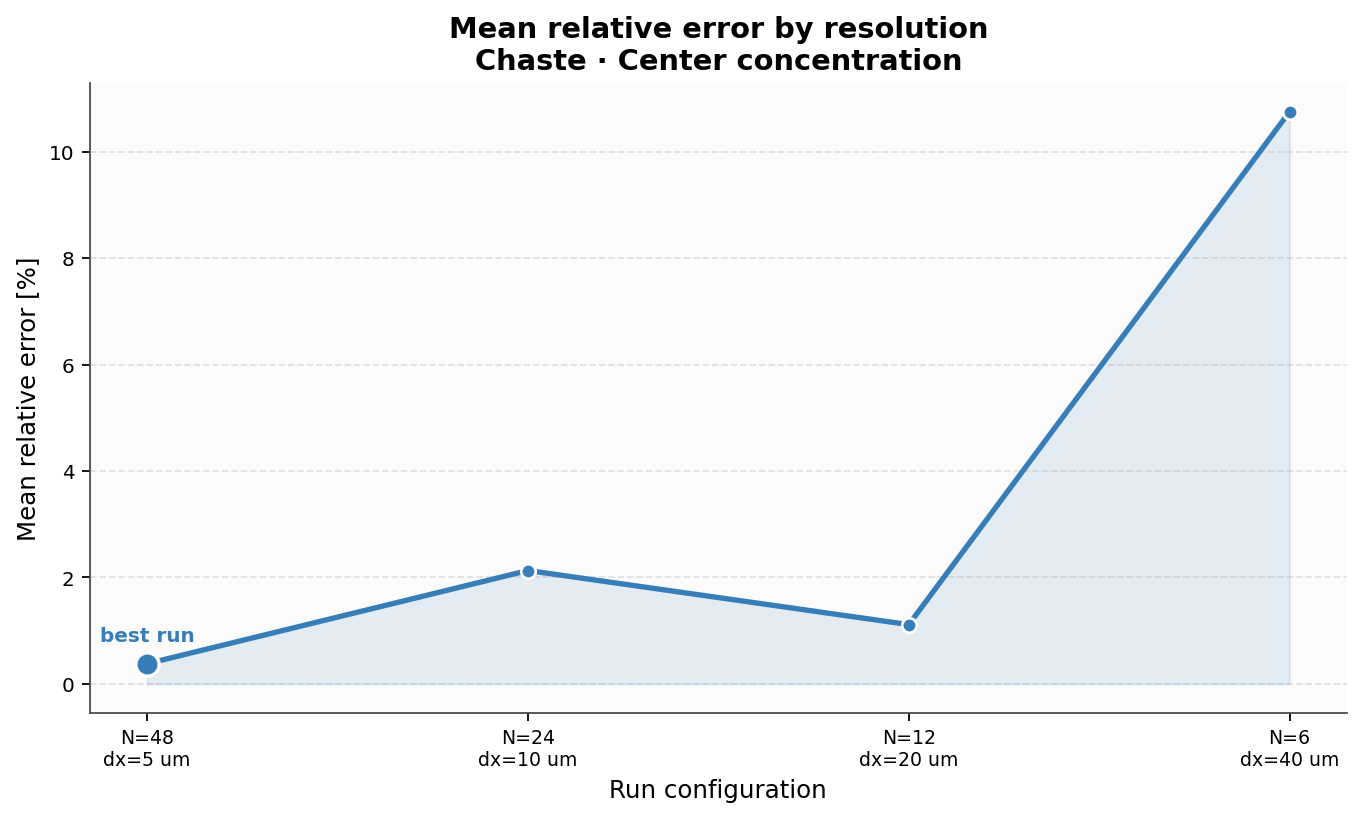

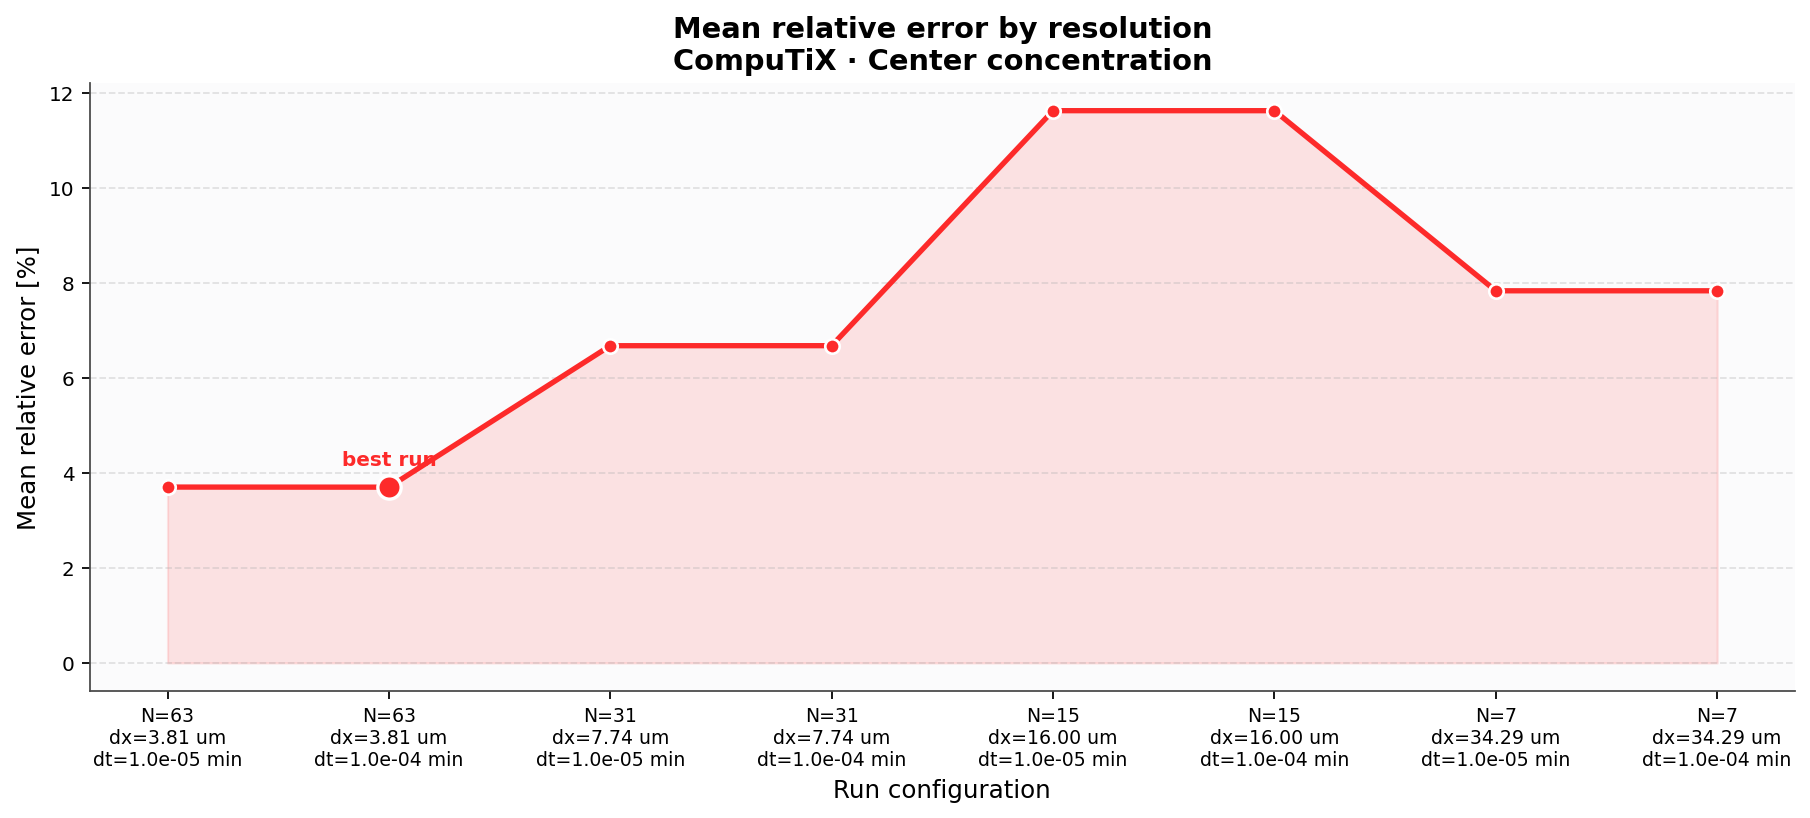

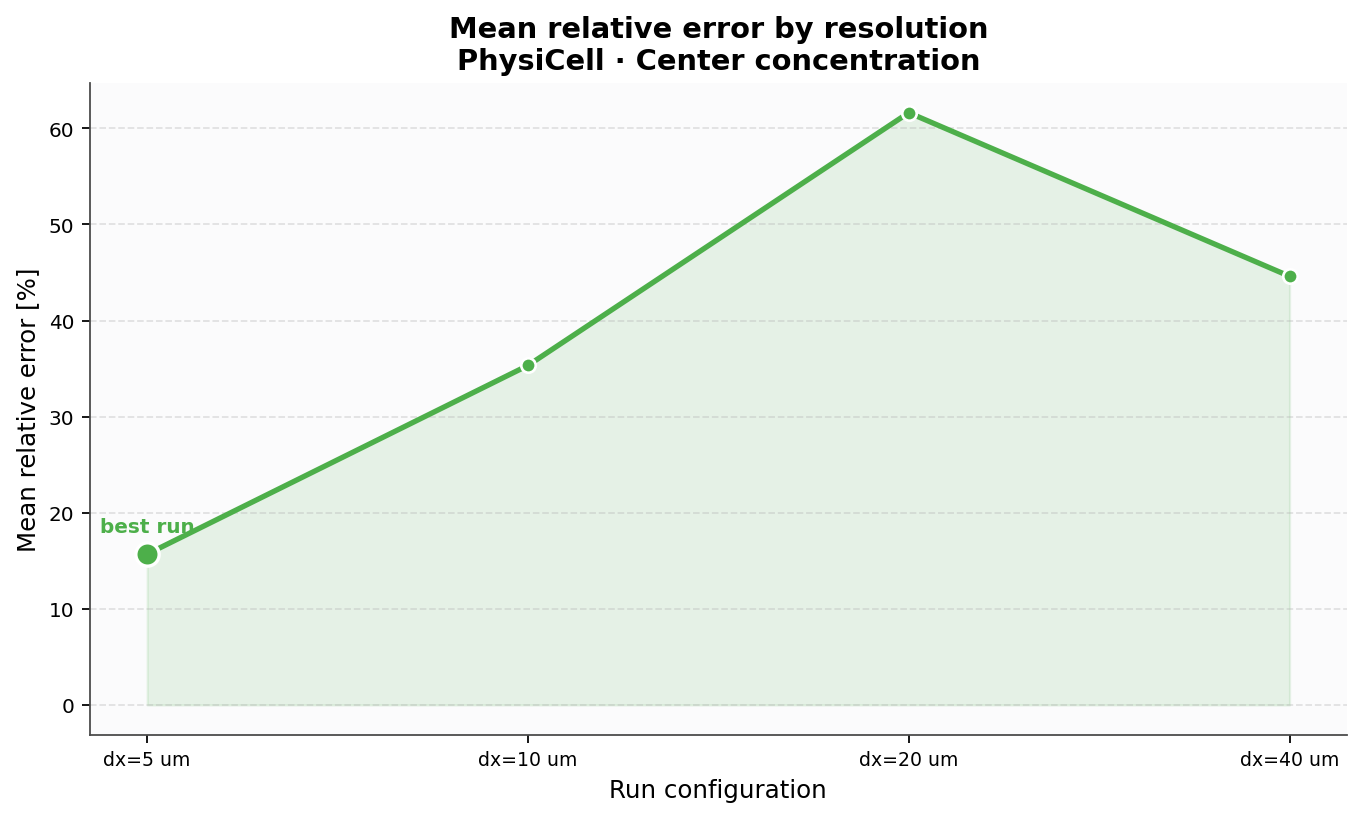

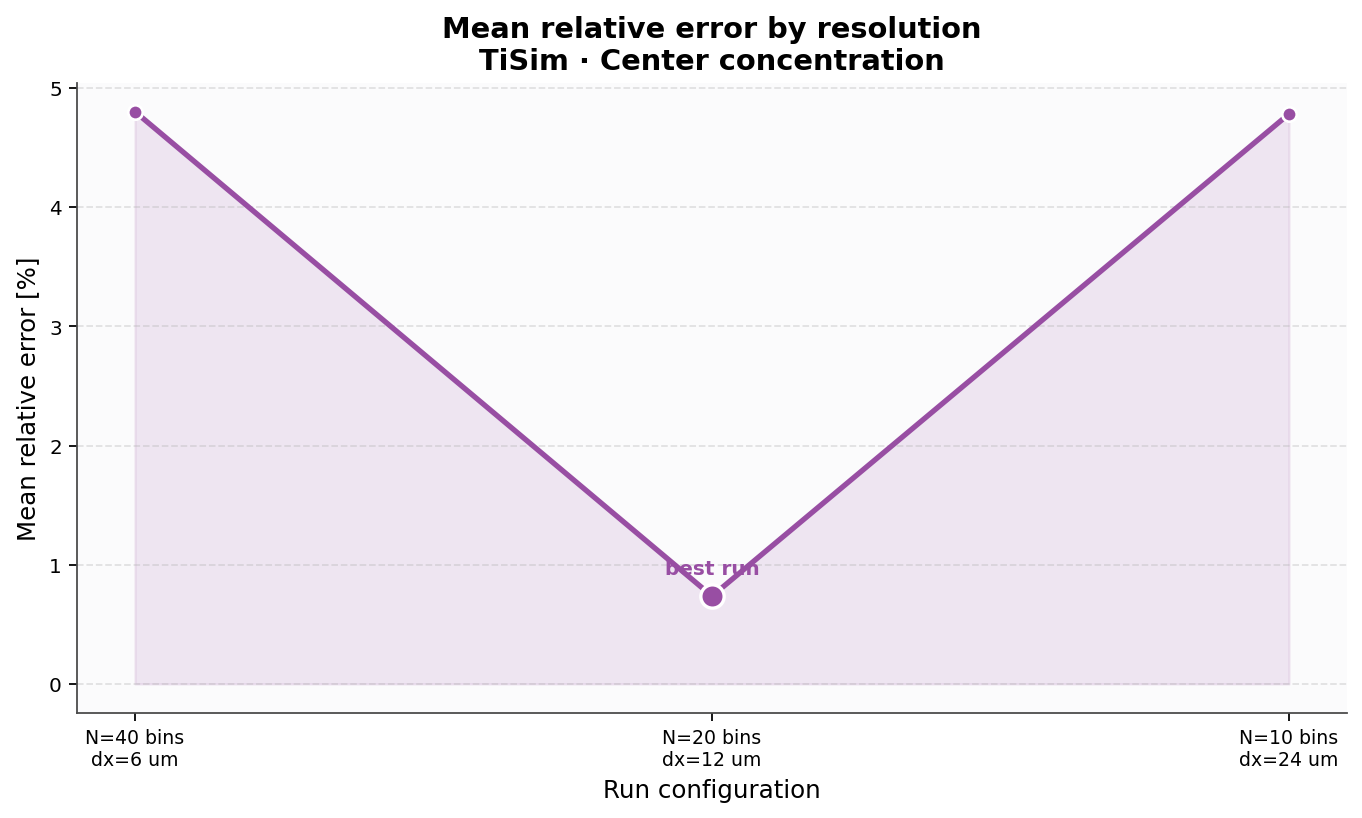

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/uptake_tools_comparison_plots


In [ ]:
tools = sorted(relative_run_metrics['tool'].unique())
metrics = ['average', 'center']

for metric_name in metrics:
    metric_metrics = relative_run_metrics[relative_run_metrics['metric'] == metric_name].copy()

    for tool_name in tools:
        tool_metrics = metric_metrics[metric_metrics['tool'] == tool_name].copy()
        tool_metrics = tool_metrics.sort_values(['dx_um', 'dt_min'], na_position='last').reset_index(drop=True)

        tick_labels = []
        for row in tool_metrics.itertuples():
            if tool_name in {'BioDynaMo', 'Chaste'}:
                tick_labels.append(f'N={int(round(240 / row.dx_um))}\ndx={row.dx_um:.0f} um')
            elif tool_name == 'CompuTiX':
                tick_labels.append(f'N={int(round(240 / row.dx_um))}\ndx={row.dx_um:.2f} um\ndt={row.dt_min:.1e} min')
            elif tool_name == 'TiSim':
                tick_labels.append(f'N={int(round(240 / row.dx_um))} bins\ndx={row.dx_um:.0f} um')
            else:
                tick_labels.append(f'dx={row.dx_um:.0f} um')

        x_positions = np.arange(len(tool_metrics))
        y_values = tool_metrics['mean_relative_error_percent']
        best_position = int(y_values.argmin())
        figure_width = 8.4 if len(tool_metrics) <= 4 else 11.2

        fig, axis = plt.subplots(figsize=(figure_width, 5.0), constrained_layout=True)
        axis.plot(
            x_positions,
            y_values,
            color=tool_colors[tool_name],
            linewidth=2.4,
            marker='o',
            markersize=6.5,
            markeredgecolor='white',
            markeredgewidth=1.2,
        )
        axis.fill_between(x_positions, y_values, color=tool_colors[tool_name], alpha=0.12)
        axis.scatter(
            x_positions[best_position],
            y_values.iloc[best_position],
            s=110,
            color=tool_colors[tool_name],
            edgecolor='white',
            linewidth=1.5,
            zorder=3,
        )
        axis.annotate(
            'best run',
            (x_positions[best_position], y_values.iloc[best_position]),
            xytext=(0, 10),
            textcoords='offset points',
            ha='center',
            fontsize=9,
            color=tool_colors[tool_name],
            fontweight='semibold',
        )

        axis.set_xticks(x_positions)
        axis.set_xticklabels(tick_labels, rotation=0, ha='center')
        axis.tick_params(axis='x', labelsize=8.5)
        axis.set_ylabel('Mean relative error [%]')
        axis.set_xlabel('Run configuration')
        axis.set_title(f'Mean relative error by resolution\n{tool_name} · {metric_titles[metric_name]}')
        axis.margins(x=0.05)
        style_axis(axis)

        save_and_show(fig, f'mean_relative_error_{metric_file_tokens[metric_name]}_{tool_name.lower()}_uptake.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 5: Keep Only The Best Resolution Per Tool And Per Metric

Now we select the run with the smallest mean relative error inside each tool family, separately for the whole-box average and for the center concentration.

This shows which resolution is closest to the analytical solution for each tool under each comparison metric.

In [ ]:
relative_best_runs = (
    relative_run_metrics.sort_values(['metric', 'tool', 'mean_relative_error_percent', 'dx_um', 'dt_min'])
    .groupby(['metric', 'tool'], as_index=False)
    .first()
    .sort_values(['metric', 'mean_relative_error_percent'])
)

relative_best_runs

,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_relative_error_percent,max_relative_error_percent,rmse_percent
2,average,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min",100,0.050187,0.065777,0.054671
0,average,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.077446,0.098523,0.083367
4,average,TiSim,TiSim_N_40,6.00000,NaN,"N=40 bins, dx=6 um",101,0.104070,0.131964,0.111983
1,average,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.128856,0.151674,0.133328
3,average,PhysiCell,PhysiCell_dx_5um_uptake,5.00000,NaN,voxel size=5 um,101,0.775070,0.883206,0.802004
5,center,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.201284,0.252523,0.211279
6,center,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.380480,0.426879,0.383773
9,center,TiSim,TiSim_N_20,12.00000,NaN,"N=20 bins, dx=12 um",101,0.737177,0.875830,0.758906
7,center,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.00010,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min",100,3.698101,3.798662,3.719853
8,center,PhysiCell,PhysiCell_dx_5um_uptake,5.00000,NaN,voxel size=5 um,101,15.693821,16.831432,15.916278


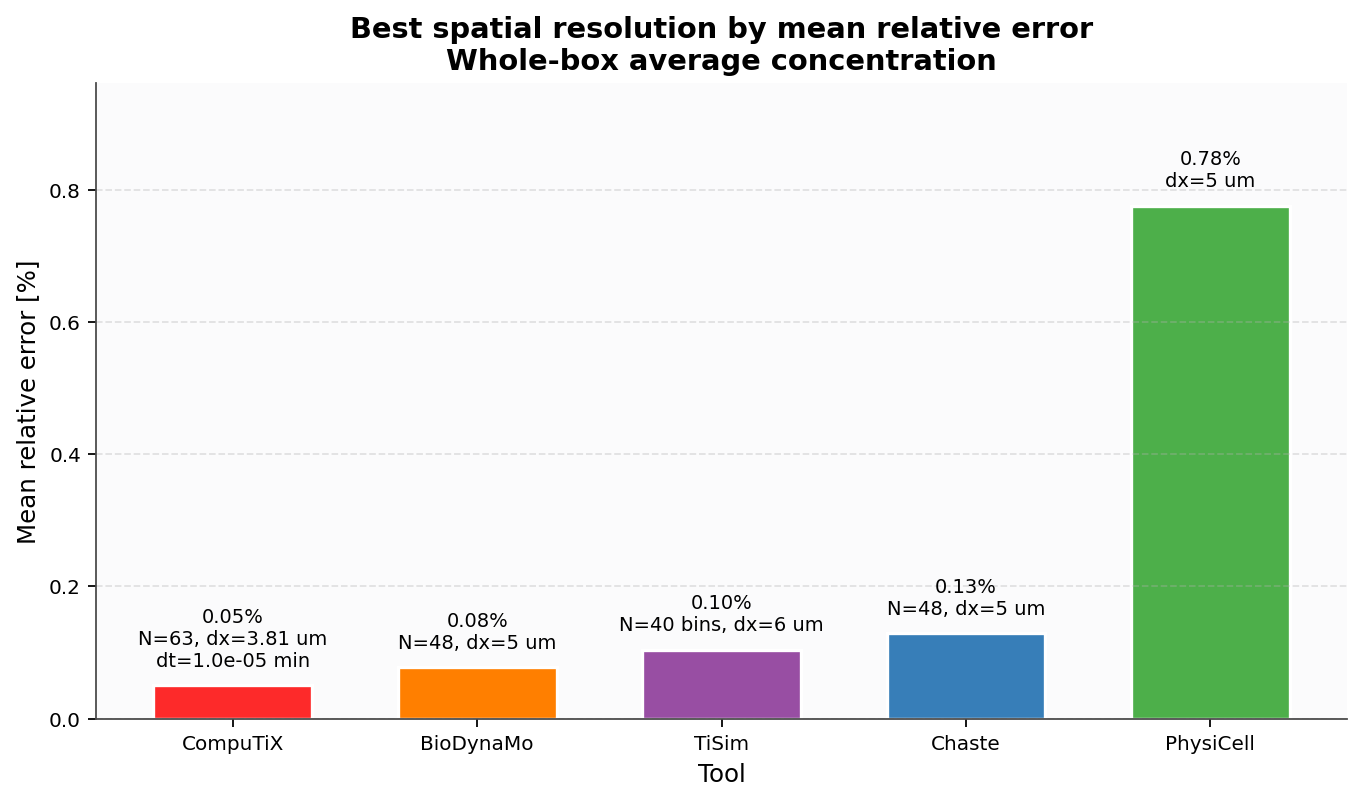

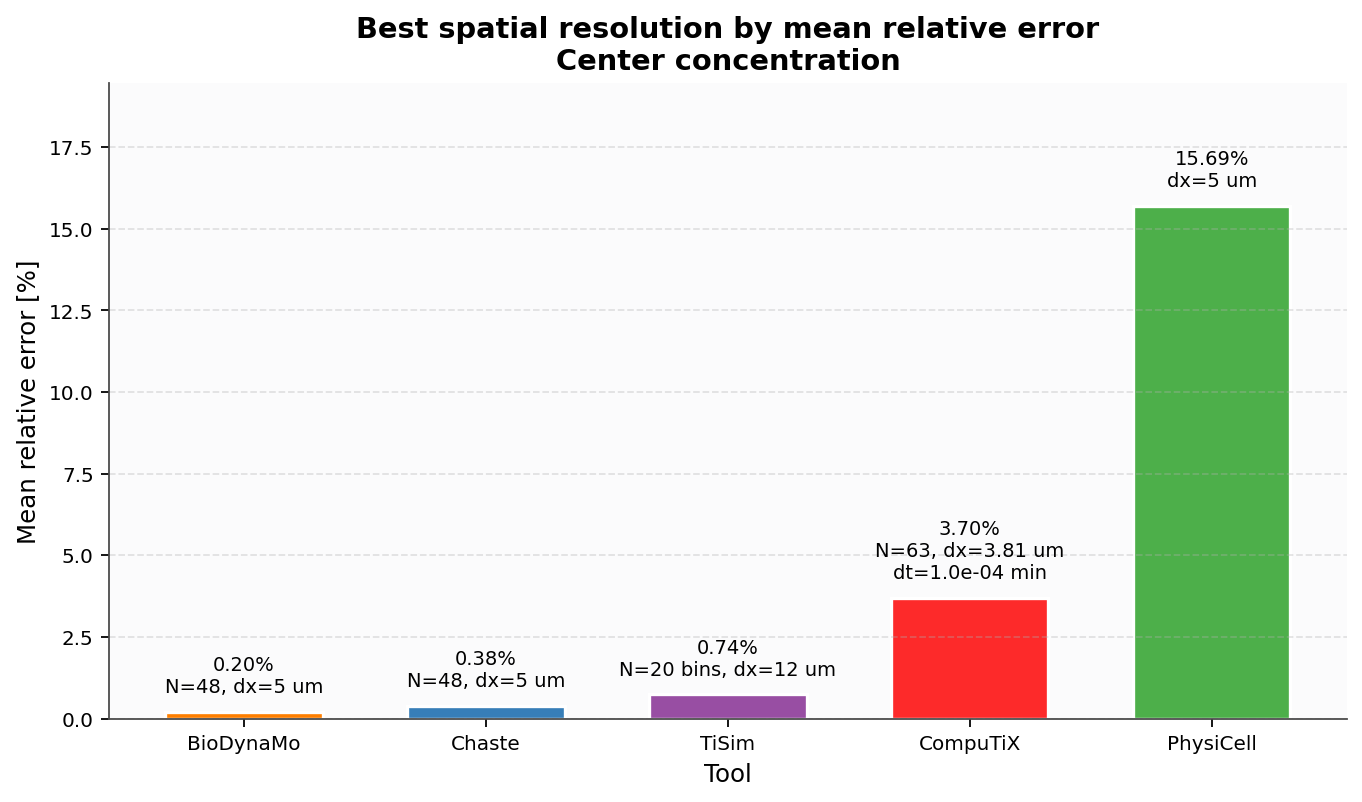

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/uptake_tools_comparison_plots


In [ ]:
for metric_name in ['average', 'center']:
    metric_best = relative_best_runs[relative_best_runs['metric'] == metric_name].sort_values('mean_relative_error_percent').reset_index(drop=True)

    fig, axis = plt.subplots(figsize=(8.4, 4.9), constrained_layout=True)
    bars = axis.bar(
        metric_best['tool'],
        metric_best['mean_relative_error_percent'],
        width=0.65,
        color=[tool_colors[tool_name] for tool_name in metric_best['tool']],
        edgecolor='white',
        linewidth=1.5,
    )

    for bar, (_, row) in zip(bars, metric_best.iterrows()):
        if row['tool'] == 'CompuTiX':
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.2f} um\ndt={row['dt_min']:.1e} min"
        elif row['tool'] in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.0f} um"
        elif row['tool'] == 'TiSim':
            resolution_text = f"N={int(round(240 / row['dx_um']))} bins, dx={row['dx_um']:.0f} um"
        else:
            resolution_text = f"dx={row['dx_um']:.0f} um"

        axis.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + 0.03 * metric_best['mean_relative_error_percent'].max(),
            f"{row['mean_relative_error_percent']:.2f}%\n{resolution_text}",
            ha='center',
            va='bottom',
            fontsize=8.8,
        )

    axis.set_ylabel('Mean relative error [%]')
    axis.set_xlabel('Tool')
    axis.set_title(f'Best spatial resolution by mean relative error\n{metric_titles[metric_name]}')
    axis.set_ylim(0, metric_best['mean_relative_error_percent'].max() * 1.24)
    style_axis(axis)

    save_and_show(fig, f'best_relative_resolution_{metric_file_tokens[metric_name]}_uptake.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 6: Plot The Relative Error Over Time For Only The Best Runs

This is the first final comparison: one relative-error curve per tool for the best run selected under the whole-box average metric, and one relative-error curve per tool for the best run selected under the center metric.

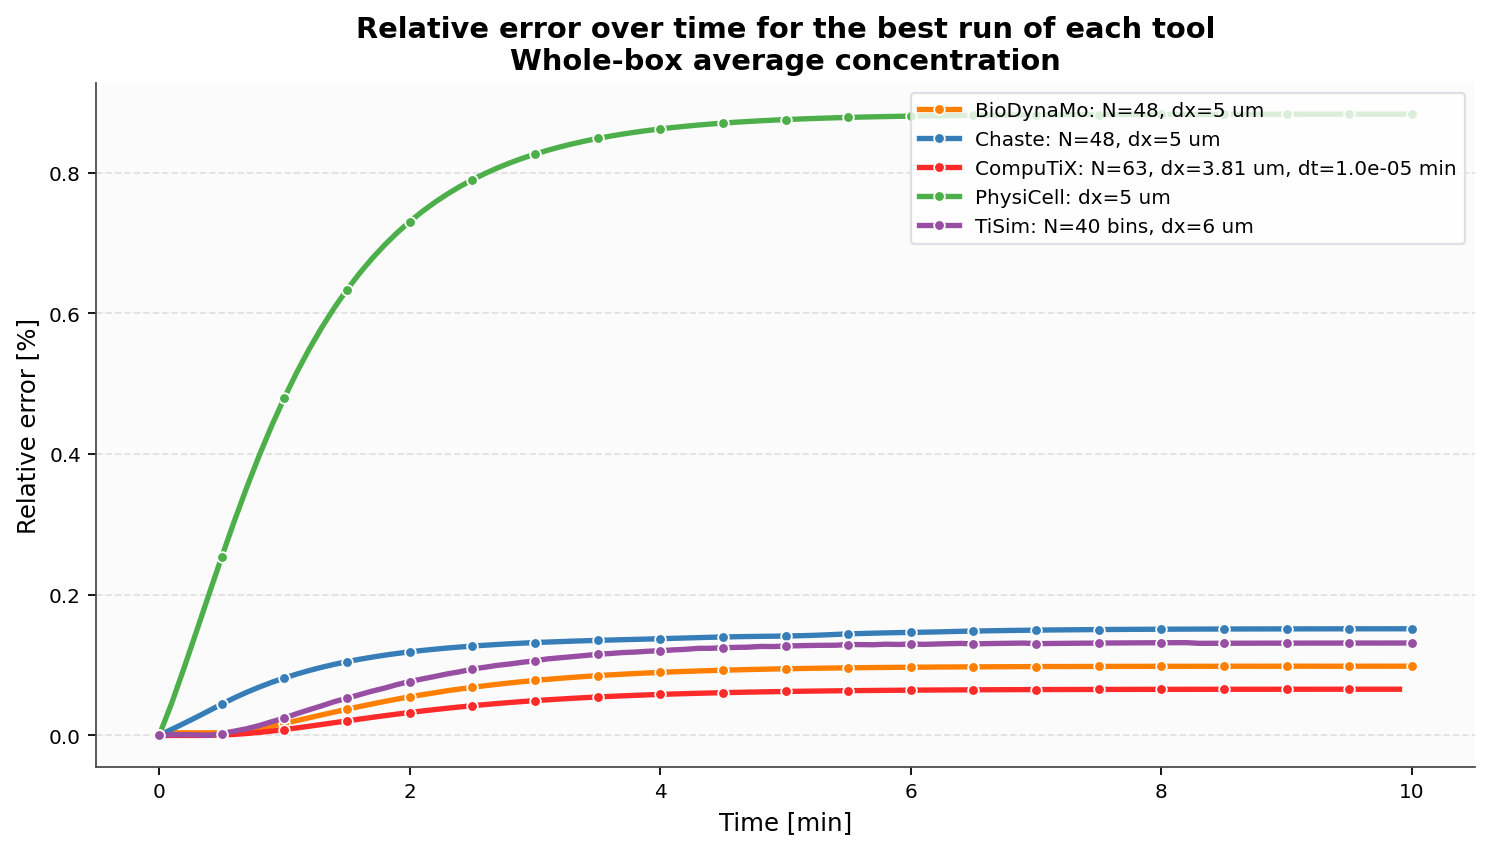

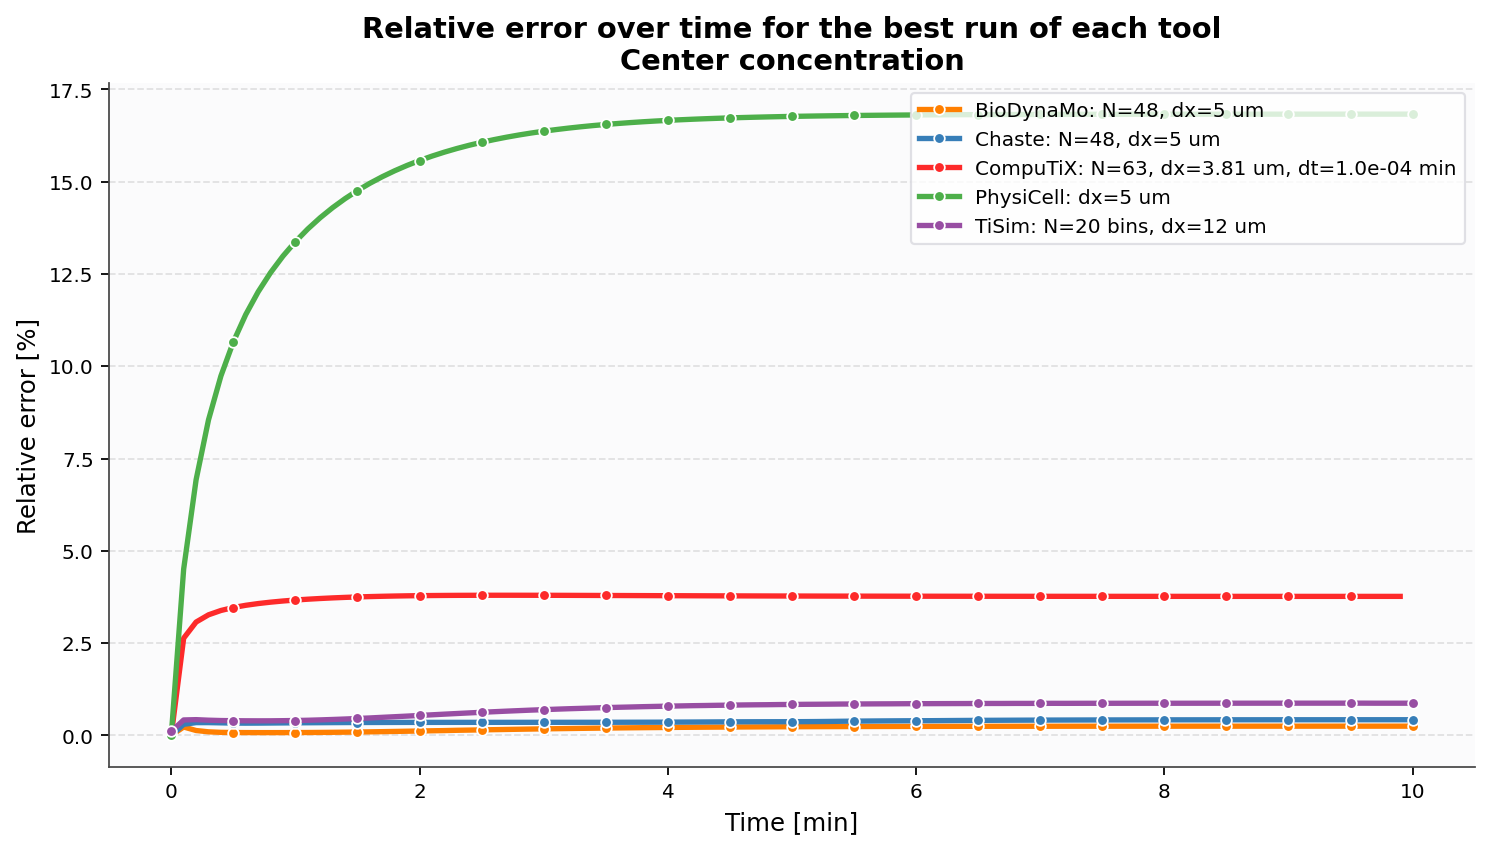

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/uptake_tools_comparison_plots


In [ ]:
for metric_name in ['average', 'center']:
    metric_best_runs = relative_best_runs[relative_best_runs['metric'] == metric_name][['tool', 'run_id']]
    metric_comparison = comparison[comparison['metric'] == metric_name].merge(
        metric_best_runs,
        on=['tool', 'run_id'],
        how='inner',
        validate='many_to_one',
    )

    fig, axis = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)

    for tool_name, group in metric_comparison.groupby('tool'):
        group = group.sort_values('time_min').reset_index(drop=True)
        marker_step = max(len(group) // 18, 1)

        if tool_name == 'CompuTiX':
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.2f} um, dt={group['dt_min'].iloc[0]:.1e} min"
        elif tool_name in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.0f} um"
        elif tool_name == 'TiSim':
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))} bins, dx={group['dx_um'].iloc[0]:.0f} um"
        else:
            resolution_text = f"dx={group['dx_um'].iloc[0]:.0f} um"

        axis.plot(
            group['time_min'],
            group['relative_error_percent'],
            color=tool_colors[tool_name],
            linewidth=2.4,
            marker='o',
            markersize=4.8,
            markeredgecolor='white',
            markeredgewidth=0.8,
            markevery=marker_step,
            label=f"{tool_name}: {resolution_text}",
        )

    axis.set_xlabel('Time [min]')
    axis.set_ylabel('Relative error [%]')
    axis.set_title(f'Relative error over time for the best run of each tool\n{metric_titles[metric_name]}')
    style_axis(axis)
    axis.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#d9d9df')

    save_and_show(fig, f'relative_error_over_time_{metric_file_tokens[metric_name]}_uptake.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 7: Keep Only The Best Resolution Per Tool And Per Metric Using Absolute Error

Now we repeat the same selection step using mean absolute error instead of mean relative error.

This identifies the best run for each tool under the whole-box average metric and under the center metric when the comparison is measured in uM.

In [ ]:
absolute_best_runs = (
    absolute_run_metrics.sort_values(['metric', 'tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])
    .groupby(['metric', 'tool'], as_index=False)
    .first()
    .sort_values(['metric', 'mean_absolute_error_uM'])
)

absolute_best_runs

,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_absolute_error_uM,max_absolute_error_uM,rmse_uM
2,average,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min",100,0.004913,0.006435,0.005351
0,average,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.007582,0.009639,0.008159
4,average,TiSim,TiSim_N_40,6.00000,NaN,"N=40 bins, dx=6 um",101,0.010189,0.012911,0.010960
1,average,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.012622,0.014839,0.013055
3,average,PhysiCell,PhysiCell_dx_5um_uptake,5.00000,NaN,voxel size=5 um,101,0.075923,0.086411,0.078531
5,center,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.014513,0.020570,0.015191
6,center,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.027554,0.030476,0.027760
9,center,TiSim,TiSim_N_20,12.00000,NaN,"N=20 bins, dx=12 um",101,0.053175,0.062529,0.054515
7,center,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.00010,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min",100,0.267945,0.276227,0.269331
8,center,PhysiCell,PhysiCell_dx_5um_uptake,5.00000,NaN,voxel size=5 um,101,1.132721,1.201655,1.145895


## Step 8: Plot The Absolute Error For The Best Run Of Each Tool

This is the second final comparison: one absolute-error curve per tool for the best run selected under the whole-box average metric, and one absolute-error curve per tool for the center metric.

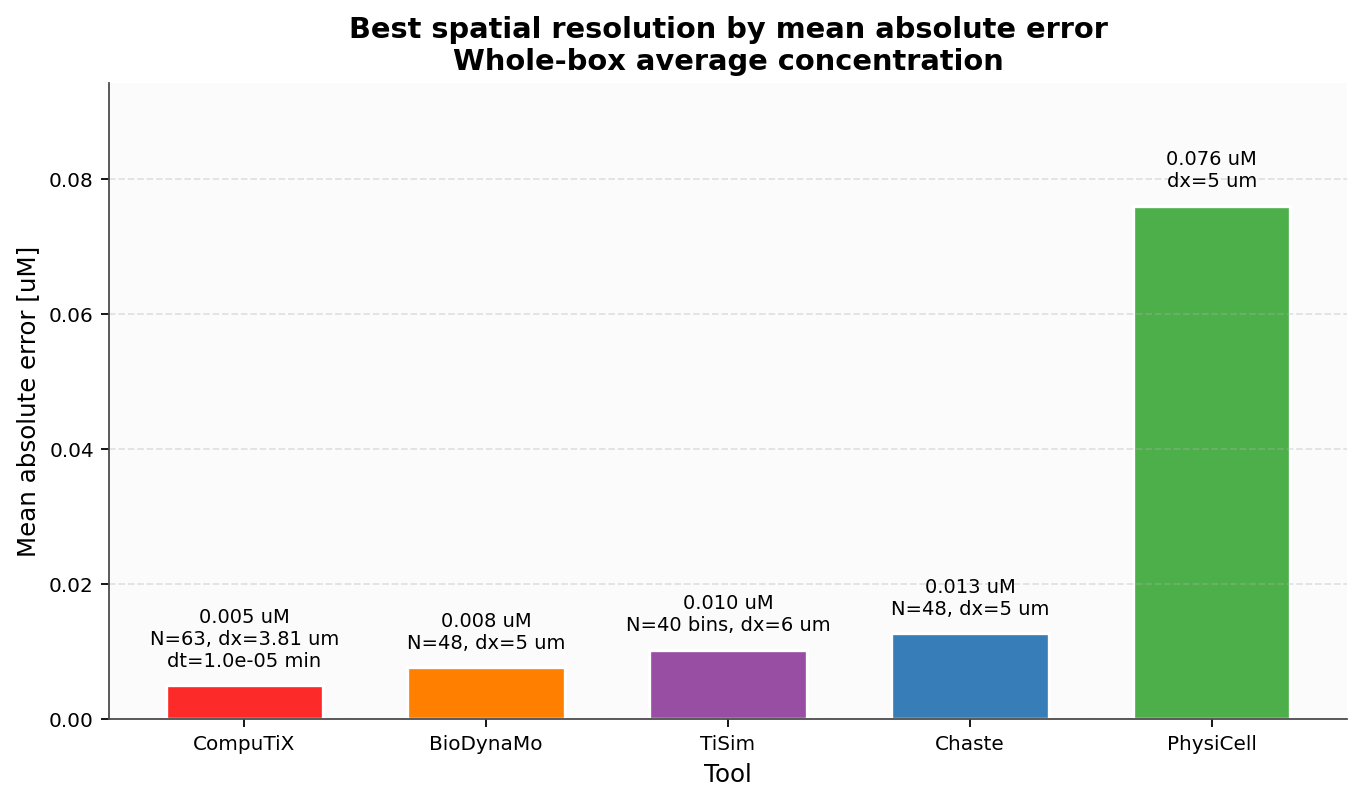

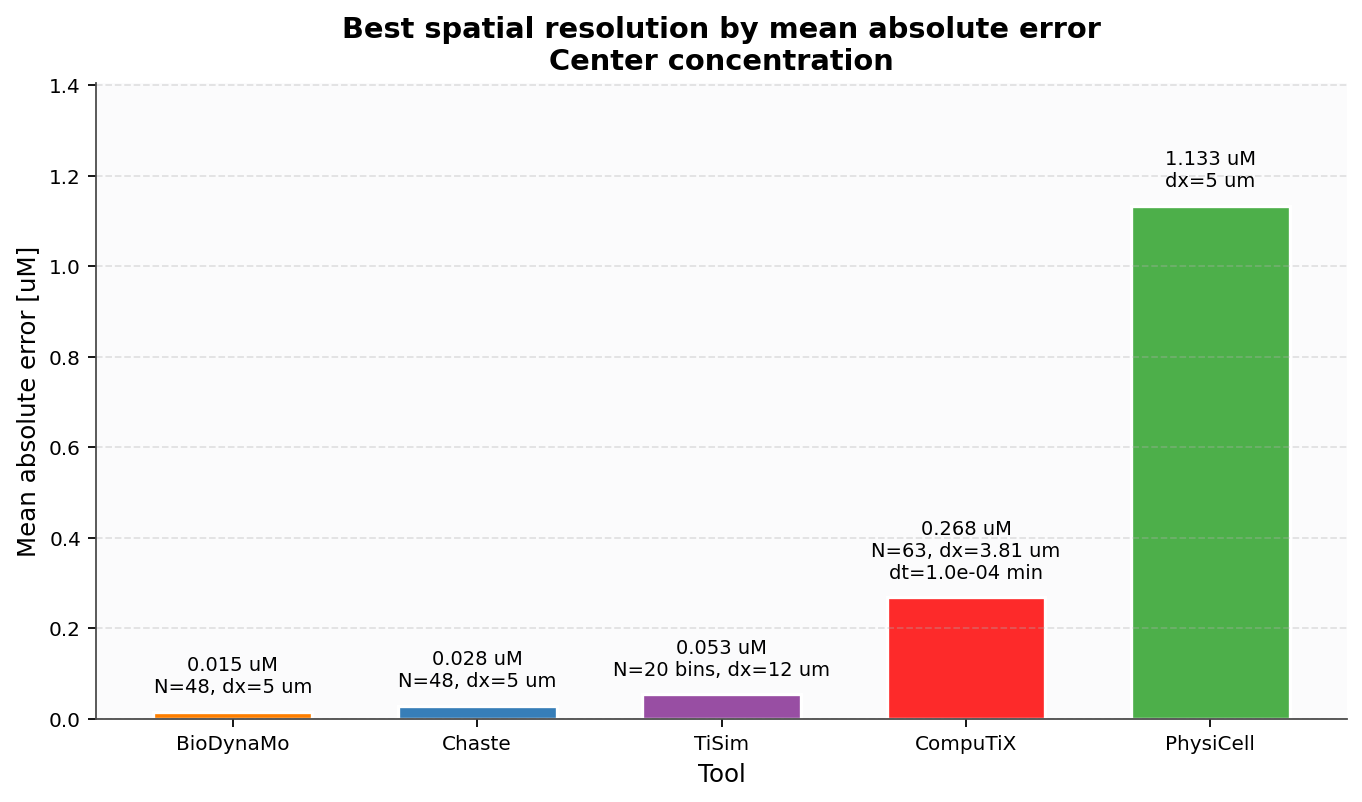

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/uptake_tools_comparison_plots


In [ ]:
for metric_name in ['average', 'center']:
    metric_best = absolute_best_runs[absolute_best_runs['metric'] == metric_name].sort_values('mean_absolute_error_uM').reset_index(drop=True)

    fig, axis = plt.subplots(figsize=(8.4, 4.9), constrained_layout=True)
    bars = axis.bar(
        metric_best['tool'],
        metric_best['mean_absolute_error_uM'],
        width=0.65,
        color=[tool_colors[tool_name] for tool_name in metric_best['tool']],
        edgecolor='white',
        linewidth=1.5,
    )

    for bar, (_, row) in zip(bars, metric_best.iterrows()):
        if row['tool'] == 'CompuTiX':
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.2f} um\ndt={row['dt_min']:.1e} min"
        elif row['tool'] in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / row['dx_um']))}, dx={row['dx_um']:.0f} um"
        elif row['tool'] == 'TiSim':
            resolution_text = f"N={int(round(240 / row['dx_um']))} bins, dx={row['dx_um']:.0f} um"
        else:
            resolution_text = f"dx={row['dx_um']:.0f} um"

        axis.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() + 0.03 * metric_best['mean_absolute_error_uM'].max(),
            f"{row['mean_absolute_error_uM']:.3f} uM\n{resolution_text}",
            ha='center',
            va='bottom',
            fontsize=8.8,
        )

    axis.set_ylabel('Mean absolute error [uM]')
    axis.set_xlabel('Tool')
    axis.set_title(f'Best spatial resolution by mean absolute error\n{metric_titles[metric_name]}')
    axis.set_ylim(0, metric_best['mean_absolute_error_uM'].max() * 1.24)
    style_axis(axis)

    save_and_show(fig, f'best_absolute_resolution_{metric_file_tokens[metric_name]}_uptake.png')

print(f'Saved standalone plots to {plot_output_dir}')

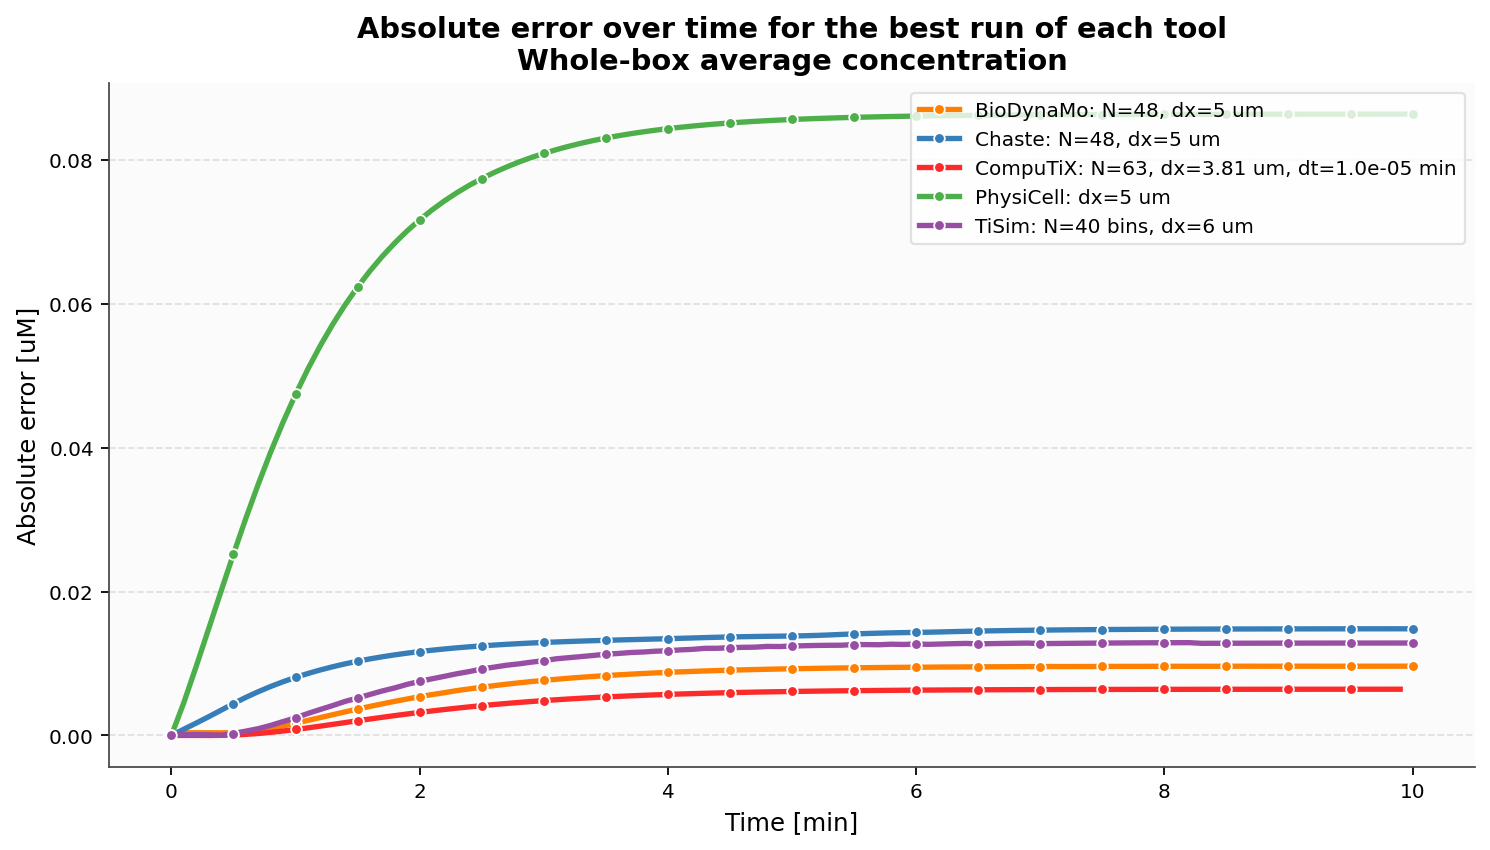

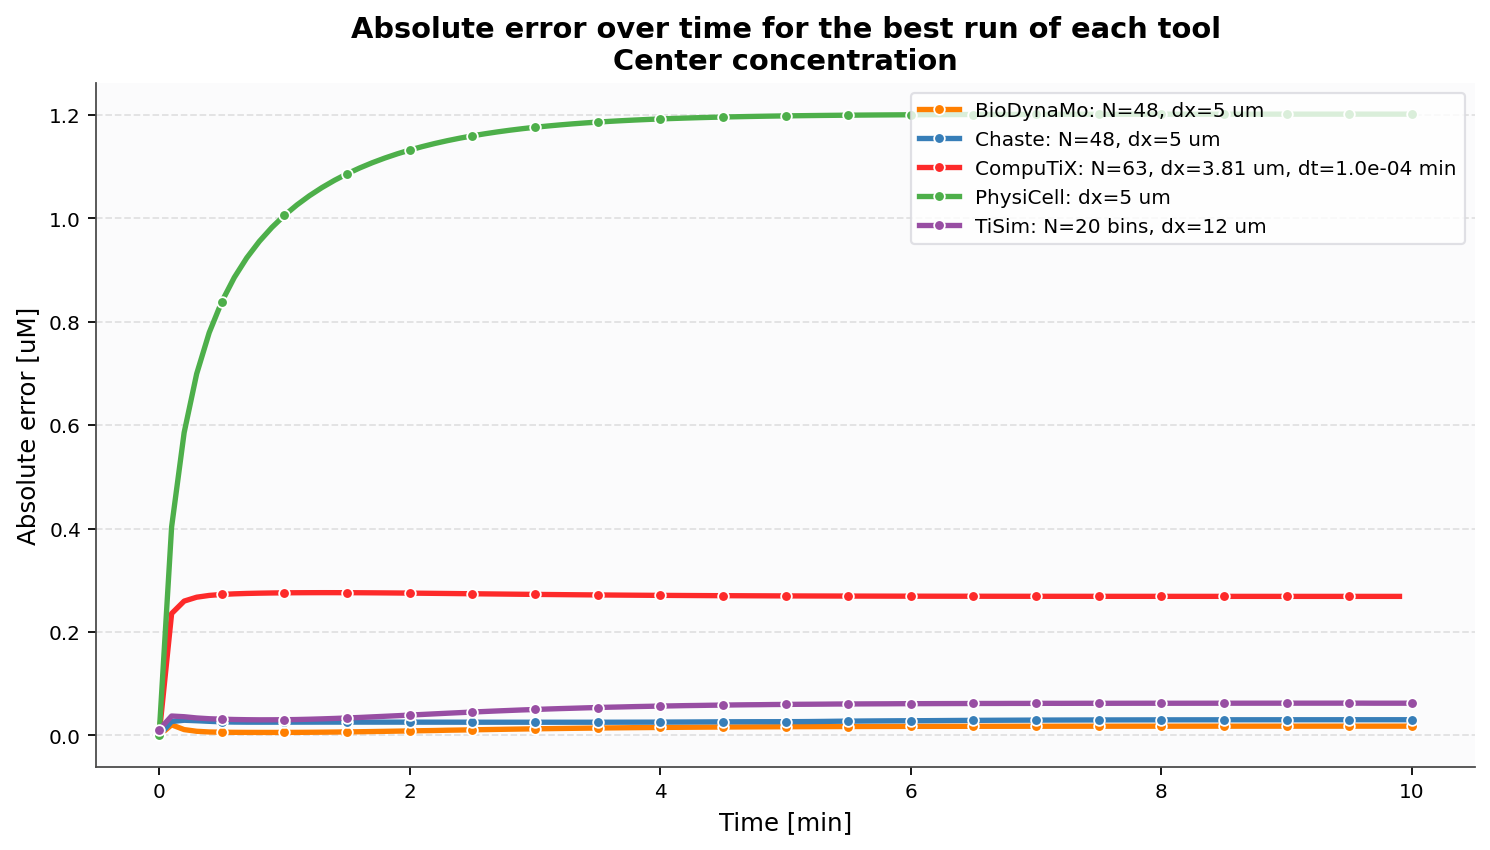

Saved standalone plots to /home/tntiniak/Work/observatory_benchmark/ResultAnalysis/uptake_tools_comparison_plots


In [ ]:
for metric_name in ['average', 'center']:
    metric_best_runs = absolute_best_runs[absolute_best_runs['metric'] == metric_name][['tool', 'run_id']]
    metric_comparison = comparison[comparison['metric'] == metric_name].merge(
        metric_best_runs,
        on=['tool', 'run_id'],
        how='inner',
        validate='many_to_one',
    )

    fig, axis = plt.subplots(figsize=(9.2, 5.2), constrained_layout=True)

    for tool_name, group in metric_comparison.groupby('tool'):
        group = group.sort_values('time_min').reset_index(drop=True)
        marker_step = max(len(group) // 18, 1)

        if tool_name == 'CompuTiX':
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.2f} um, dt={group['dt_min'].iloc[0]:.1e} min"
        elif tool_name in {'BioDynaMo', 'Chaste'}:
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))}, dx={group['dx_um'].iloc[0]:.0f} um"
        elif tool_name == 'TiSim':
            resolution_text = f"N={int(round(240 / group['dx_um'].iloc[0]))} bins, dx={group['dx_um'].iloc[0]:.0f} um"
        else:
            resolution_text = f"dx={group['dx_um'].iloc[0]:.0f} um"

        axis.plot(
            group['time_min'],
            group['absolute_error_uM'],
            color=tool_colors[tool_name],
            linewidth=2.4,
            marker='o',
            markersize=4.8,
            markeredgecolor='white',
            markeredgewidth=0.8,
            markevery=marker_step,
            label=f"{tool_name}: {resolution_text}",
        )

    axis.set_xlabel('Time [min]')
    axis.set_ylabel('Absolute error [uM]')
    axis.set_title(f'Absolute error over time for the best run of each tool\n{metric_titles[metric_name]}')
    style_axis(axis)
    axis.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#d9d9df')

    save_and_show(fig, f'absolute_error_over_time_{metric_file_tokens[metric_name]}_uptake.png')

print(f'Saved standalone plots to {plot_output_dir}')

## Step 9: Recompute Errors With Interpolated Analytical Values

This section keeps the original rounded-time matching workflow intact and adds a second comparison path where the analytical reference is interpolated directly onto each simulation time grid.

The goal is to compare the two alignment strategies side by side before deciding which one is the better basis for cross-tool benchmarking.

In [ ]:
interpolation_reference = (
    analytical_df.groupby('time_min', as_index=False)[
        ['average_concentration_uM', 'center_concentration_uM']
    ]
    .mean()
    .sort_values('time_min')
)

interpolation_time_min = interpolation_reference['time_min'].to_numpy(dtype=float)
interpolation_average_uM = interpolation_reference['average_concentration_uM'].to_numpy(dtype=float)
interpolation_center_uM = interpolation_reference['center_concentration_uM'].to_numpy(dtype=float)

interpolated_comparison = all_runs.copy()
interpolated_comparison['analytical_average_uM'] = np.interp(
    interpolated_comparison['time_min'].to_numpy(dtype=float),
    interpolation_time_min,
    interpolation_average_uM,
 )
interpolated_comparison['analytical_center_uM'] = np.interp(
    interpolated_comparison['time_min'].to_numpy(dtype=float),
    interpolation_time_min,
    interpolation_center_uM,
 )

interpolated_average = interpolated_comparison.assign(
    metric='average',
    simulated_uM=interpolated_comparison['average_uM'],
    analytical_uM=interpolated_comparison['analytical_average_uM'],
    source_column=interpolated_comparison['average_source'],
)

interpolated_center = interpolated_comparison.assign(
    metric='center',
    simulated_uM=interpolated_comparison['center_uM'],
    analytical_uM=interpolated_comparison['analytical_center_uM'],
    source_column=interpolated_comparison['center_source'],
)

interpolated_comparison = pd.concat([interpolated_average, interpolated_center], ignore_index=True)
interpolated_comparison['relative_error_percent'] = (
    100.0
    * (interpolated_comparison['simulated_uM'] - interpolated_comparison['analytical_uM']).abs()
    / interpolated_comparison['analytical_uM'].abs()
)
interpolated_comparison['absolute_error_uM'] = (
    interpolated_comparison['simulated_uM'] - interpolated_comparison['analytical_uM']
 ).abs()

interpolated_relative_run_metrics = (
    interpolated_comparison.groupby(['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'], dropna=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_relative_error_percent=('relative_error_percent', 'mean'),
        max_relative_error_percent=('relative_error_percent', 'max'),
        rmse_percent=('relative_error_percent', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .reset_index()
    .sort_values(['metric', 'tool', 'mean_relative_error_percent', 'dx_um', 'dt_min'])
)

interpolated_best_runs = (
    interpolated_relative_run_metrics
    .sort_values(['metric', 'tool', 'mean_relative_error_percent', 'dx_um', 'dt_min'])
    .groupby(['metric', 'tool'], as_index=False)
    .first()
    .sort_values(['metric', 'mean_relative_error_percent'])
)

interpolated_absolute_run_metrics = (
    interpolated_comparison.groupby(['metric', 'tool', 'run_id', 'dx_um', 'dt_min', 'resolution_label'], dropna=False)
    .agg(
        point_count=('time_min', 'size'),
        mean_absolute_error_uM=('absolute_error_uM', 'mean'),
        max_absolute_error_uM=('absolute_error_uM', 'max'),
        rmse_uM=('absolute_error_uM', lambda values: np.sqrt(np.mean(np.square(values)))),
    )
    .reset_index()
    .sort_values(['metric', 'tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])
)

interpolated_absolute_best_runs = (
    interpolated_absolute_run_metrics
    .sort_values(['metric', 'tool', 'mean_absolute_error_uM', 'dx_um', 'dt_min'])
    .groupby(['metric', 'tool'], as_index=False)
    .first()
    .sort_values(['metric', 'mean_absolute_error_uM'])
)

interpolated_relative_run_metrics

,metric,tool,run_id,dx_um,dt_min,resolution_label,point_count,mean_relative_error_percent,max_relative_error_percent,rmse_percent
2,average,BioDynaMo,BioDynaMo_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",10000,0.077582,0.098524,0.083447
1,average,BioDynaMo,BioDynaMo_N_24,10.00000,NaN,"N=24 voxels/dim, dx=10 um",10000,0.160917,0.202279,0.172573
0,average,BioDynaMo,BioDynaMo_N_12,20.00000,NaN,"N=12 voxels/dim, dx=20 um",1000,0.322662,0.401167,0.344997
3,average,BioDynaMo,BioDynaMo_N_6,40.00000,NaN,"N=6 voxels/dim, dx=40 um",1000,0.693661,0.835663,0.733291
6,average,Chaste,Chaste_N_48,5.00000,NaN,"N=48 voxels/dim, dx=5 um",101,0.128856,0.151674,0.133328
5,average,Chaste,Chaste_N_24,10.00000,NaN,"N=24 voxels/dim, dx=10 um",101,0.245328,0.283071,0.253879
4,average,Chaste,Chaste_N_12,20.00000,NaN,"N=12 voxels/dim, dx=20 um",101,0.454250,0.523153,0.470540
7,average,Chaste,Chaste_N_6,40.00000,NaN,"N=6 voxels/dim, dx=40 um",101,0.832717,0.962698,0.864638
13,average,CompuTiX,CompuTiX_N_63_dt_1e-05min,3.80952,0.00001,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-05 min",100,0.050187,0.065777,0.054671
12,average,CompuTiX,CompuTiX_N_63_dt_0.0001min,3.80952,0.00010,"N=63 voxels/dim, dx=3.81 um, dt=1.0e-04 min",100,0.051535,0.067551,0.056143
